# End-to-End House Price Prediction using Multiple Linear Regression

## Project Overview
This notebook implements an end-to-end Machine Learning pipeline to predict home values based on demographic, structural, and geographic attributes.

### Objectives
1. Perform Exploratory Data Analysis (EDA) and feature correlation analysis.
2. Preprocess data via train-test splitting and feature scaling (`StandardScaler`).
3. Train an Ordinary Least Squares (OLS) Multiple Linear Regression model.
4. Evaluate performance using $R^2$ Score and Root Mean Squared Error (RMSE).
5. Analyze residual errors to validate linear regression assumptions.

In [15]:
# Import core libraries for data handling, plotting, and machine learning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configure plot styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Environment setup complete and libraries imported successfully.")

Environment setup complete and libraries imported successfully.


## Step 1: Data Ingestion and Structural Inspection

We load the **California Housing Dataset** from `scikit-learn`. 
The target variable is **`MedHouseVal`** (Median house value in hundreds of thousands of dollars, e.g., $2.0 = $200,000).

### Features in this dataset:
* `MedInc`: Median income in block group
* `HouseAge`: Median house age in block group
* `AveRooms`: Average number of rooms per household
* `AveBedrms`: Average number of bedrooms per household
* `Population`: Block group population
* `AveOccup`: Average number of household members
* `Latitude` / `Longitude`: Geographic location parameters

In [16]:
# Fetch dataset as a Pandas DataFrame
raw_data = fetch_california_housing(as_frame=True)
df = raw_data.frame

# Display shape and basic statistics
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Missing values per feature:")
print(df.isnull().sum())

# Inspect the top 5 records
df.head()

Dataset Dimensions: 20640 rows, 9 columns

Missing values per feature:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 2: Exploratory Data Analysis (EDA) & Correlation Heatmap

Before fitting a model, we examine how numerical features correlate with our target (`MedHouseVal`).
Linear regression relies on linear relationships; features with high positive or negative correlation carry the most predictive signal.

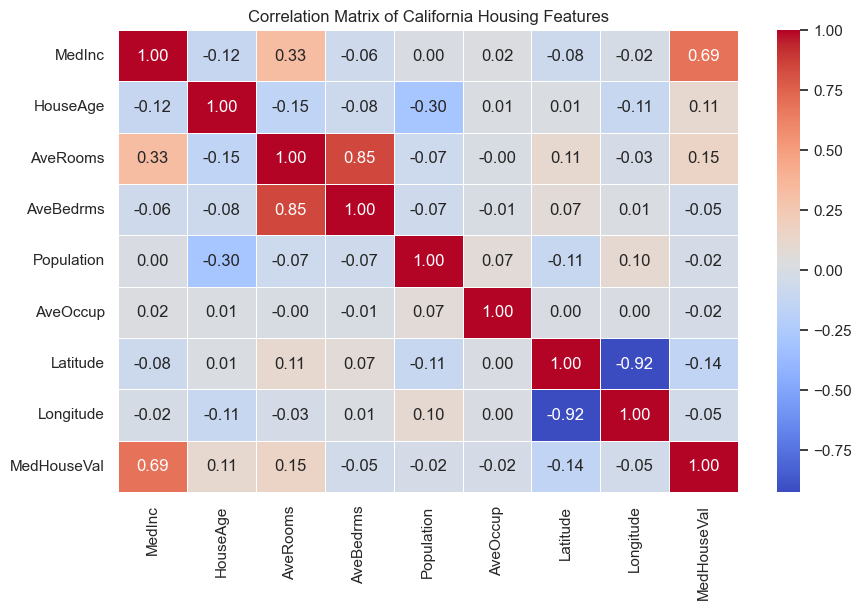

Correlation relative to Target Variable (MedHouseVal):

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [17]:
# Plot correlation matrix
plt.figure(figsize=(10, 6))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of California Housing Features")
plt.show()

# Print strongest correlations relative to MedHouseVal
target_corr = correlation_matrix["MedHouseVal"].sort_values(ascending=False)
print("Correlation relative to Target Variable (MedHouseVal):\n")
print(target_corr)

## Step 3: Train-Test Split and Feature Scaling

### Why Train-Test Split?
We split our dataset into **80% Training Data** and **20% Testing Data** to evaluate how well our model generalizes to unseen data.

### Why Feature Scaling?
Linear regression computes coefficients based on feature magnitudes. Features with huge numbers (e.g., `Population` in thousands) can artificially dominate smaller scale features (e.g., `MedInc` in single digits). We use **`StandardScaler`** to give all features a mean of 0 and a variance of 1:

$$z = \frac{x - \mu}{\sigma}$$

In [18]:
# Separate features (X) and target variable (y)
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit scaler on Training set ONLY to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape:  {X_test_scaled.shape}")

X_train shape: (16512, 8)
X_test shape:  (4128, 8)


## Step 4: Model Training & Feature Coefficient Analysis

We fit an **Ordinary Least Squares (OLS) Linear Regression** model. The model learns a linear equation:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

By inspecting the learned weights ($\beta$), we can see which features positively or negatively influence house prices.

In [19]:
# Instantiate and fit Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Store coefficients in a clean Pandas DataFrame
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Standardized Coefficient Weight': model.coef_
}).sort_values(by='Standardized Coefficient Weight', ascending=False)

print(f"Model Intercept (y-bias): {model.intercept_:.4f}\n")
print("Learned Feature Weights:")
coefficients

Model Intercept (y-bias): 2.0719

Learned Feature Weights:


,Feature,Standardized Coefficient Weight
0,MedInc,0.854383
3,AveBedrms,0.339259
1,HouseAge,0.122546
4,Population,-0.002308
5,AveOccup,-0.040829
2,AveRooms,-0.294410
7,Longitude,-0.869842
6,Latitude,-0.896929


## Step 5: Predictions & Evaluation Metrics

We run the trained model on our held-out test data (`X_test_scaled`) and evaluate performance using two core metrics:
1. **Root Mean Squared Error (RMSE):** Measures average magnitude of prediction errors in actual target units ($100,000s). Lower is better.
2. **$R^2$ Score (Coefficient of Determination):** Measures the proportion of variance in house prices explained by our model (0% to 100%). Higher is better.

In [20]:
# Predict test set values
y_pred = model.predict(X_test_scaled)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance Metrics ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} ($100,000 units)")
print(f"Mean Absolute Error (MAE):     {np.mean(np.abs(y_test - y_pred)):.4f}")
print(f"R² Score (Variance Explained): {r2:.4f} ({r2*100:.2f}%)")

--- Model Performance Metrics ---
Root Mean Squared Error (RMSE): 0.7456 ($100,000 units)
Mean Absolute Error (MAE):     0.5332
R² Score (Variance Explained): 0.5758 (57.58%)


## Step 6: Residual Diagnostics

Linear regression assumes that error residuals ($e = y_{\text{true}} - y_{\text{pred}}$) are randomly distributed around 0 (**homoscedasticity**).

If the residual plot shows an obvious pattern (like a curve or funnel), it indicates that the relationship between features and target is non-linear and would benefit from non-linear algorithms (e.g., Polynomial Features, Decision Trees, or XGBoost).

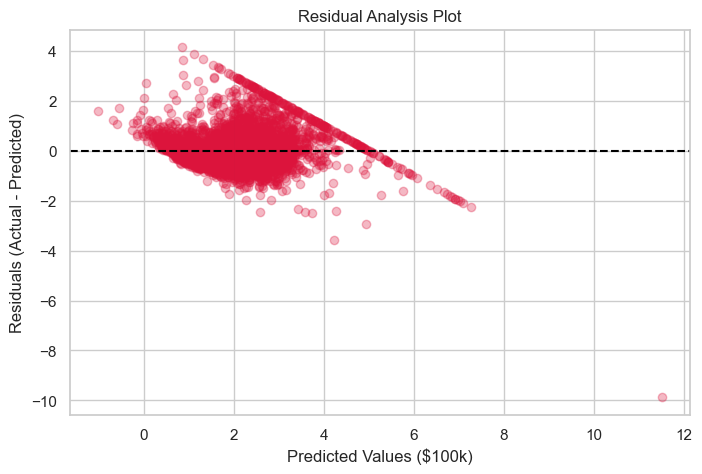

In [21]:
# Compute residuals
residuals = y_test - y_pred

# Plot predicted vs. residuals
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3, color='crimson')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel("Predicted Values ($100k)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Analysis Plot")
plt.show()